In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")


In [116]:
# Đọc dữ liệu từ tệp
df_FPT_4_2_3 = pd.read_csv("./DATA EXPLORER CONTEST/Data - 12ndMar/4.2.3.FPT.csv")
df_FPT_4_2_4 = pd.read_csv("./DATA EXPLORER CONTEST/Data - 12ndMar/4.2.4.FPT.csv")
df_cafef = pd.read_excel("daily_dominant_sentiment_no_title.xlsx")
df_EPS = pd.read_csv("EPS_FPT.csv")
df_Loi_nhuan = pd.read_csv("bang_loi_nhuan.csv")

In [126]:
# Đổi kiểu dữ liệu của cột 'Date'
df_FPT_4_2_3['Date'] = pd.to_datetime(df_FPT_4_2_3['Date'], format='%d/%m/%Y')
df_FPT_4_2_4['Date'] = pd.to_datetime(df_FPT_4_2_4['Date'], format='%d/%m/%Y')
df_cafef['Date'] = pd.to_datetime(df_cafef['Date'], format='%d/%m/%Y')
df_EPS['Date'] = pd.to_datetime(df_EPS['Date'], format='%d/%m/%Y')
df_Loi_nhuan['Date'] = pd.to_datetime(df_Loi_nhuan['Date'], format='%d/%m/%Y')


# Hợp nhất dữ liệu theo 'Date'
merged_df = pd.merge(df_FPT_4_2_3, df_cafef, on='Date', how='left')
merged_df = pd.merge(merged_df, df_FPT_4_2_4, on='Date', how='left')
merged_df = pd.merge(merged_df, df_EPS, on='Date', how='left')
merged_df = pd.merge(merged_df, df_Loi_nhuan, on='Date', how='left')


# Điền mặc định cho các giá trị bị thiếu
merged_df['sentiment'] = merged_df['sentiment'].fillna('neutral')
merged_df['sentiment_score'] = merged_df['sentiment_score'].fillna(1)

# Kiểm tra dữ liệu sau khi hợp nhất
merged_df.head()

,StockID_x,Date,Total Volume,Total Value,Market Cap,Closing Price,Price Change,Price Change %,Matched Volume,Matched Value,...,Negotiated Buy Volume,Negotiated Buy Value,Negotiated Sell Volume,Negotiated Sell Value,Total Buy Volume,Total Buy Value,Total Sell Volume,Total Sell Value,EPS,Loi nhuan
0,FPT,2025-03-12,6365000,870067,199918302,135900,-1600,-1.16,6185000,844877,...,100000.0,13660.0,100000.0,13660.0,645200.0,88251.0,2806300.0,383330.0,5697,2.086990e+12
1,FPT,2025-03-11,6164400,849430,202272013,137500,-1800,-1.29,5784400,797080,...,380000.0,52351.0,380000.0,52351.0,1791550.0,246904.0,2358820.0,324361.0,5697,2.086990e+12
2,FPT,2025-03-10,5681900,796168,204919937,139300,-2100,-1.49,5323000,745248,...,193900.0,27147.0,193900.0,27147.0,1719776.0,240915.0,2865216.0,399553.0,5697,2.086990e+12
3,FPT,2025-03-07,3436000,486821,208009182,141400,-200,-0.14,2954500,418579,...,441500.0,62437.0,441500.0,62437.0,1230243.0,174185.0,1966692.0,278113.0,5697,2.086990e+12
4,FPT,2025-03-06,6511400,921080,208303396,141600,2500,1.80,6417100,907741,...,94300.0,13339.0,94300.0,13339.0,2173819.0,306839.0,2514540.0,355569.0,5697,2.086990e+12


In [127]:
# Lấy cột Date làm index cho DataFrame
merged_df.set_index('Date', inplace=True)

# Sắp xếp dữ liệu theo ngày tháng tăng dần
merged_df.sort_index(inplace=True)

# Bỏ cột không cần thiết
merged_df.drop(columns=['sentiment'], inplace=True)
merged_df.drop(columns=['StockID_x'], inplace=True)
merged_df.drop(columns=['StockID_y'], inplace=True)

# Kiểm tra dữ liệu sau khi chuyển đổi
merged_df.info()
merged_df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2024-03-26 to 2025-03-12
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Total Volume            240 non-null    int64  
 1   Total Value             240 non-null    int64  
 2   Market Cap              240 non-null    int64  
 3   Closing Price           240 non-null    int64  
 4   Price Change            240 non-null    int64  
 5   Price Change %          240 non-null    float64
 6   Matched Volume          240 non-null    int64  
 7   Matched Value           240 non-null    int64  
 8   sentiment_score         240 non-null    float64
 9   Foreign Investor Room   240 non-null    float64
 10  Remaining Room Shares   240 non-null    float64
 11  Remaining Room %        240 non-null    float64
 12  Matched Buy Volume      240 non-null    float64
 13  Matched Buy Value       240 non-null    float64
 14  Matched Sell Volume    

,Total Volume,Total Value,Market Cap,Closing Price,Price Change,Price Change %,Matched Volume,Matched Value,sentiment_score,Foreign Investor Room,...,Negotiated Buy Volume,Negotiated Buy Value,Negotiated Sell Volume,Negotiated Sell Value,Total Buy Volume,Total Buy Value,Total Sell Volume,Total Sell Value,EPS,Loi nhuan
Date,,,,,,,,,,,,,,,,,,,,,
2024-03-26,3110290,365684,146046421,115000,1000,0.88,1693300,193338,1.0,622284748.0,...,1390790.0,169537.0,1390790.0,169537.0,1390790.0,169537.0,1396990.0,170244.0,5476,1.728400e+12
2024-03-27,1467800,168909,146300414,115200,200,0.17,1320200,151372,1.0,622284748.0,...,40000.0,4920.0,40000.0,4920.0,40000.0,4920.0,41700.0,5114.0,5476,1.728400e+12
2024-03-28,2854400,333719,148713355,117100,1900,1.65,2803200,327411,2.0,622284748.0,...,51200.0,6308.0,51200.0,6308.0,51200.0,6308.0,51200.0,6308.0,5476,1.728400e+12
2024-03-29,2594300,310422,147951374,116500,-600,-0.51,1343500,156545,1.0,622284748.0,...,924600.0,115760.0,924600.0,115760.0,924600.0,115760.0,924800.0,115783.0,5476,1.728400e+12
2024-04-01,3243600,387065,148332365,116800,300,0.26,1974600,229434,2.0,622284748.0,...,799000.0,99555.0,799000.0,99555.0,800700.0,99753.0,807440.0,100527.0,5541,1.798030e+12


In [5]:
# xuất file csv
merged_df.to_csv("merged_data.csv", index=True)

# Long Short Term Memory (LSTM)

In [ ]:
# --- Lấy các cột cần thiết ---
features = ['Total Volume', 'Total Value','EPS','Loi nhuan' ,'Price Change'
            'Total Buy Volume','Total Buy Value','Total Sell Volume','Total Sell Value',
            'Matched Volume', 'Matched Value', 'sentiment_score',
            'Foreign Investor Room','Remaining Room Shares']
target = 'Closing Price'

In [137]:
# --- Chuẩn hóa dữ liệu ---
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_all = scaler_x.fit_transform(merged_df[features])
y_all = scaler_y.fit_transform(merged_df[[target]])


In [138]:
# Tạo sequence dữ liệu cho mô hình LSTM
# Số ngày dùng làm độ dài sequence
sequence_length = 70

# Tạo toàn bộ sequence (X, y)
X_seq, y_seq = [], []

for i in range(sequence_length, len(X_all)):
    X_seq.append(X_all[i-sequence_length:i])
    y_seq.append(y_all[i])

X_seq, y_seq = np.array(X_seq), np.array(y_seq)


In [139]:
# Chia tập train/test theo tỷ lệ 80/20
split_index = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

# In ra shape để kiểm tra
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (136, 70, 1) (136, 1)
Test shape: (34, 70, 1) (34, 1)


In [140]:
# -------------------- Xây dựng và huấn luyện mô hình LSTM --------------------
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Huấn luyện
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# Dự đoán
y_pred = model.predict(X_test)

# Đảo ngược chuẩn hóa để ra giá trị thật
y_pred_inverse = scaler_y.inverse_transform(y_pred)
y_test_inverse = scaler_y.inverse_transform(y_test)




Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.3197 - val_loss: 0.5877
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2140 - val_loss: 0.4065
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1109 - val_loss: 0.1023
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0226 - val_loss: 0.1053
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0221 - val_loss: 0.1073
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0174 - val_loss: 0.0703
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0175 - val_loss: 0.1039
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0212 - val_loss: 0.0867
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0192 - val_loss: 0.0992
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0201 - val_loss: 0.0831
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0215 - val_loss: 0.0959
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0177 - val_loss: 0.0922
E

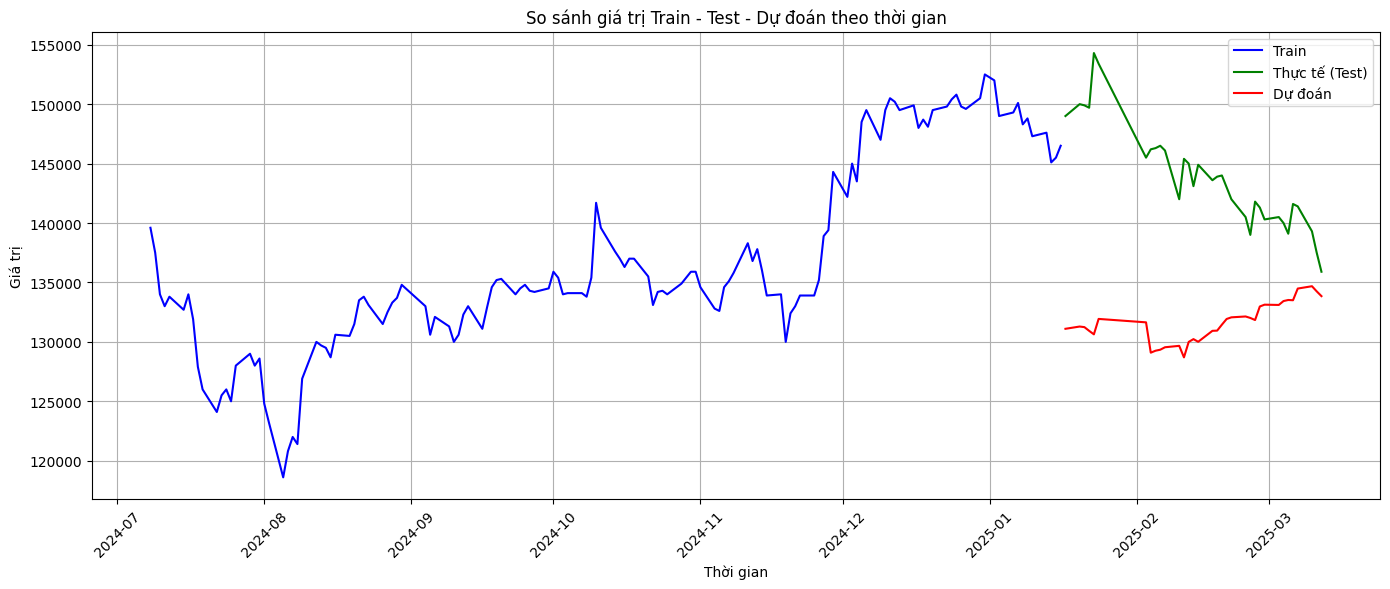

In [141]:
import matplotlib.pyplot as plt

# Lấy thời gian tương ứng với y_train
train_start_idx = sequence_length
train_end_idx = train_start_idx + len(y_train)
train_time_index = merged_df.index[train_start_idx:train_end_idx]
y_train_inverse = scaler_y.inverse_transform(y_train)

# Lấy thời gian tương ứng với y_test
test_start_idx = sequence_length + split_index
test_end_idx = test_start_idx + len(y_test)
test_time_index = merged_df.index[test_start_idx:test_end_idx]
y_test_inverse = scaler_y.inverse_transform(y_test)
y_pred_inverse = scaler_y.inverse_transform(y_pred)

# Vẽ biểu đồ tổng hợp
plt.figure(figsize=(14, 6))
plt.plot(train_time_index, y_train_inverse, label='Train', color='blue')
plt.plot(test_time_index, y_test_inverse, label='Thực tế (Test)', color='green')
plt.plot(test_time_index, y_pred_inverse, label='Dự đoán', color='red')
plt.title('So sánh giá trị Train - Test - Dự đoán theo thời gian')
plt.xlabel('Thời gian')
plt.ylabel('Giá trị')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [134]:
# --- In ra các giá trị thực tế sau khi inverse transform ---
print("Giá trị thực tế (y_test_inverse):")
print(y_pred_inverse.flatten())

Giá trị thực tế (y_test_inverse):
[141936.   141548.47 142264.45 141387.56 141577.94 140435.   140571.88
 139064.14 139810.06 141733.67 143070.05 145071.92 145139.8  145317.33
 146203.33 146301.12 147011.05 146552.88 145858.61 145610.28 144637.5
 144172.67 143398.86 142738.4  142732.25 144069.05 144573.27 144819.23
 145198.27 144731.48 144417.3  144695.7  143992.5  143805.44]


In [135]:
# --- Đánh giá mô hình ---
mse = mean_squared_error(y_test_inverse, y_pred_inverse)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
r2 = r2_score(y_test_inverse, y_pred_inverse)

# --- In kết quả ---
print(f"MSE  (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"R²   (R-squared): {r2:.4f}")

MSE  (Mean Squared Error): 31313048.26
RMSE (Root Mean Squared Error): 5595.81
MAE  (Mean Absolute Error): 4704.98
R²   (R-squared): -0.7259


# Mô hình Linear Regression

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [40]:
# Sắp xếp dữ liệu theo thời gian trước
merged_df = merged_df.sort_index()

# Tách thủ công theo thời gian: 80% train, 20% test
split_index = int(len(merged_df) * 0.8)
train_df = merged_df.iloc[:split_index]
test_df = merged_df.iloc[split_index:]

# Lấy X và y
X_train_raw = train_df[features]
y_train = train_df[target]

X_test_raw = test_df[features]
y_test = test_df[target]

# Lưu lại index (thời gian)
train_index = X_train_raw.index
test_index = X_test_raw.index



In [41]:
# --- Chuẩn hóa dữ liệu ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


In [42]:
# --- Xây mô hình ---
model = LinearRegression()
model.fit(X_train, y_train,)

# --- Dự đoán ---
y_pred = model.predict(X_test)

# --- Đánh giá mô hình ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error (MSE): 27980338.96
R² Score: -0.47


In [43]:
# Tạo DataFrame để dễ thao tác và sắp xếp
train_df = pd.DataFrame({'Giá huấn luyện': y_train}, index=train_index).sort_index()
test_df = pd.DataFrame({'Giá thực tế': y_test, 'Giá dự đoán': y_pred}, index=test_index).sort_index()



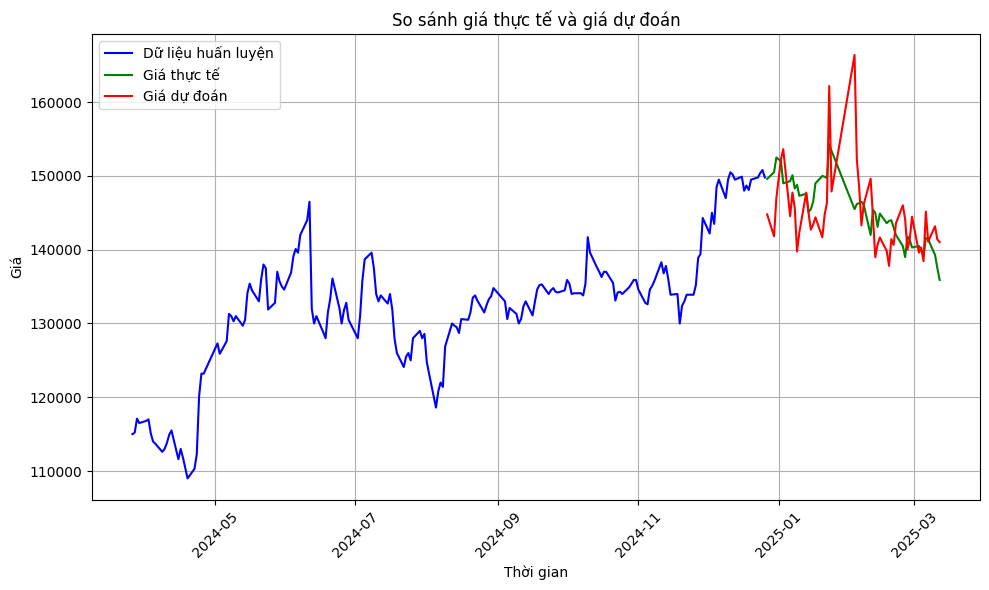

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(train_df.index, train_df['Giá huấn luyện'], label='Dữ liệu huấn luyện', color='blue')
plt.plot(test_df.index, test_df['Giá thực tế'], label='Giá thực tế', color='green')
plt.plot(test_df.index, test_df['Giá dự đoán'], label='Giá dự đoán', color='red')

plt.legend()
plt.title('So sánh giá thực tế và giá dự đoán')
plt.xlabel('Thời gian')
plt.ylabel('Giá')
plt.grid(True)
plt.xticks(rotation=45)  # Xoay nhãn thời gian cho dễ đọc
plt.tight_layout()
plt.show()


# XGBoost

In [18]:
from xgboost import XGBRegressor

In [45]:
# --- Tách tập train/test (80/20 theo thời gian) ---
split_index = int(len(merged_df) * 0.8)
train_df = merged_df.iloc[:split_index]
test_df = merged_df.iloc[split_index:]

X_train_raw = train_df[features]
y_train = train_df[target]

X_test_raw = test_df[features]
y_test = test_df[target]

# --- Chuẩn hóa dữ liệu ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# --- Huấn luyện mô hình XGBoost ---
model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# --- Dự đoán ---
y_pred = model.predict(X_test)

# --- Đánh giá mô hình ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📊 Mean Squared Error (MSE): {mse:.2f}")
print(f"📊 RMSE: {rmse:.2f}")
print(f"📈 R² Score: {r2:.4f}")

📊 Mean Squared Error (MSE): 59959412.00
📊 RMSE: 7743.35
📈 R² Score: -2.1549


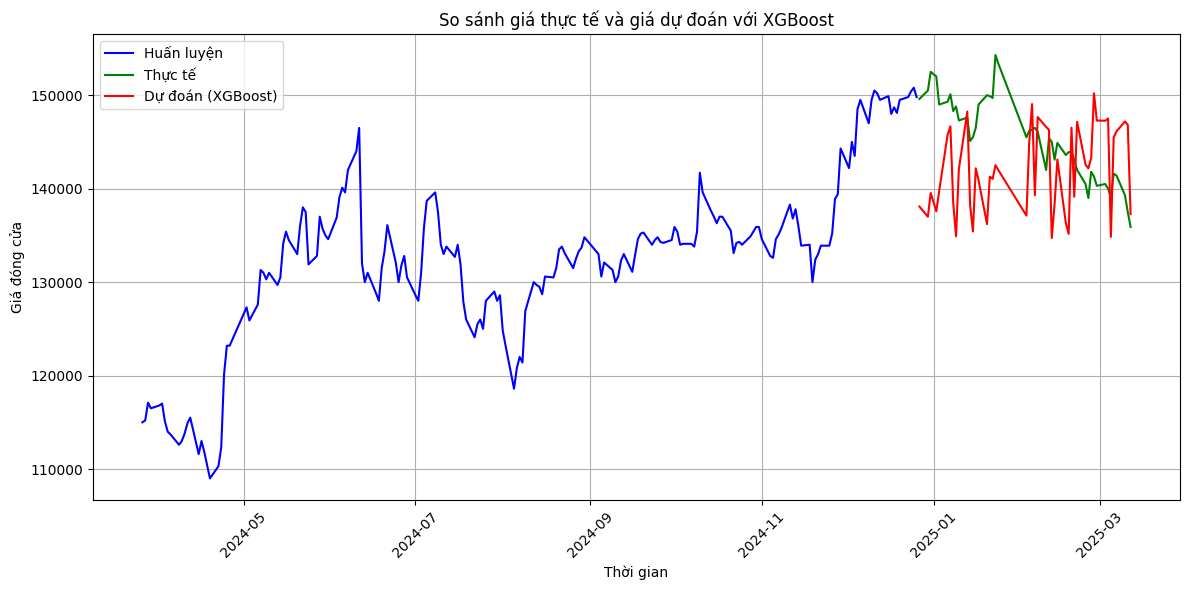

In [46]:
# Tạo DataFrame để trực quan
train_index = X_train_raw.index
test_index = X_test_raw.index

train_df_plot = pd.DataFrame({'Giá huấn luyện': y_train}, index=train_index)
test_df_plot = pd.DataFrame({'Giá thực tế': y_test, 'Giá dự đoán': y_pred}, index=test_index)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(train_df_plot.index, train_df_plot['Giá huấn luyện'], label='Huấn luyện', color='blue')
plt.plot(test_df_plot.index, test_df_plot['Giá thực tế'], label='Thực tế', color='green')
plt.plot(test_df_plot.index, test_df_plot['Giá dự đoán'], label='Dự đoán (XGBoost)', color='red')

plt.title('So sánh giá thực tế và giá dự đoán với XGBoost')
plt.xlabel('Thời gian')
plt.ylabel('Giá đóng cửa')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()